In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import gradio as gr
import numpy as np
import tensorflow as tf
from PIL import Image
import cv2

c:\Users\Kombee\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import struct
import os

def read_idx(filename):
    with open(filename, 'rb') as f:
        magic, size = struct.unpack(">II", f.read(8))
        
        if magic == 2051: 
            rows, cols = struct.unpack(">II", f.read(8))
            data = np.fromfile(f, dtype=np.uint8).reshape(size, rows, cols)
        elif magic == 2049: 
            data = np.fromfile(f, dtype=np.uint8)
        else:
            raise ValueError(f"Invalid magic number {magic} in {filename}")
        return data
base_path = 'dataset'
try:
    X_train = read_idx(os.path.join(base_path, 'train-images-idx3-ubyte/train-images-idx3-ubyte'))
    y_train = read_idx(os.path.join(base_path, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte'))
    X_test  = read_idx(os.path.join(base_path, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte'))
    y_test  = read_idx(os.path.join(base_path, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte'))

    print("✅ Data loaded successfully!")
    print(f"X_train shape: {X_train.shape}") 
except Exception as e:
    print(f"❌ Error: {e}")
    for root, dirs, files in os.walk(base_path):
        for file in files:
            print(os.path.join(root, file))

✅ Data loaded successfully!
X_train shape: (60000, 28, 28)


In [4]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [5]:
X_train.min(), X_train.max(), X_test.min(), X_test.max()

(np.uint8(0), np.uint8(255), np.uint8(0), np.uint8(255))

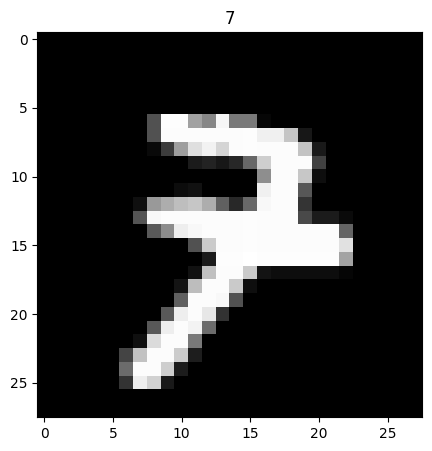

In [6]:
random_num = np.random.randint(0, len(X_train))
plt.figure(figsize=(5, 5))
plt.imshow(X_train[random_num], cmap='gray')
plt.title(y_train[random_num])
plt.show()

In [7]:
X_train = X_train.reshape(-1, 784) / 255
X_test = X_test.reshape(-1, 784) / 255

In [8]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 784), (60000,), (10000, 784), (10000,))

In [9]:
X_train.min(), X_train.max(), X_test.min(), X_test.max()

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

In [10]:
X_train[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [11]:
y_train[0]

np.uint8(5)

In [12]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.summary()

c:\Users\Kombee\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=10, validation_split=0.1)

test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_acc}')


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9872 - loss: 0.0406 - val_accuracy: 0.9882 - val_loss: 0.0410
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9883 - loss: 0.0391 - val_accuracy: 0.9865 - val_loss: 0.0572
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9870 - loss: 0.0399 - val_accuracy: 0.9887 - val_loss: 0.0418
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9880 - loss: 0.0376 - val_accuracy: 0.9877 - val_loss: 0.0431
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9888 - loss: 0.0328 - val_accuracy: 0.9870 - val_loss: 0.0460
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9888 - loss: 0.0346 - val_accuracy: 0.9863 - val_loss: 0.0488
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9880 - loss: 0.0377 - val_accuracy: 0.9882 - val_loss: 0.0508
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9897 - loss: 0.0331 - 

In [16]:
model.save('mnist_model.h5')
print("Model saved as mnist_model.h5")

Model saved as mnist_model.h5
